# 数据科学/数据处理的通用框架流程

文件来源： 此文件出自Python For Beginner学习社群。

作者： 闫小峰

Last Update: 2025-04-15

## 数据处理通用框架/流程模板

[0. 业务理解 Understanding](#0) 

[1. 数据获取和理解 ](#1)
- 数据分析环境设置 Set Up Environment
- 数据获取/采样
- 数据探索  
  - 熟悉数据属性
  - 数据体检： Sanity Checking 

[2. 预处理 Data Preparation](#2)  
- 数据清理  Data Cleaning 
- 数据准备，转换和调整


[3. 数据分析和挖掘 Data Analysis / Data  Mining](#3)
- 传统（经典）数据分析： 
  - 统计学方法 
  - 建模： 业务分析模型
- 机器学习 Machine Learning: 
  - 模型构建: 训练-测试-调试， 
  - 模型预测
- AI增强/辅助型数据分析和开发
  - LLM

[4. 模型评估  Model Evaluation ](#4)


[5. 业务理解/知识深化和提升](#5)
- 数据处理流程自动化 Pipelines
- X by Data Based/Data Driven
   -  Decision Making
   -  Story Line
   -  逻辑论证
   -  发现规律 etc

# 0.业务理解Understanding

- 目标和需求分析：数据分析的背景，动机和目的：
  - 学习如何从大数据中挖掘信息和使用价值
      - 数据类型：金融数据
      - 来源：美国股市历史数据， 。。。
  - 学习金融领域的基本和底层模型，并学会使用金融模型结合结合经典统计学（和现代机器学习算法）进行分析
  - 学习提出自己的假设并利用上述知识进行验证
  - 将学习的金融知识融入到实战中，运用场景：资产配置
- 操作执行战术分析：数据分析需要的方法
  - 灵活使用numpy和pandas的数据结构进行数据处理和计算，并熟练掌握两者之间的互相转换
  - 学会调用函数（创建，导入自创库，Function Call）

### 1. 数据获取和理解 Get Data & Data Understanding <a id="1"></a>

### 1.1. 数据处理环境设置 Set Up Environment <a id="1.1"></a>

In [1]:
# import modules for data science 
import numpy as np
import pandas as pd

#import module for plotting
import matplotlib.pyplot as plt 

import warnings
warnings.filterwarnings('ignore') #to suppress warning messages

%load_ext autoreload
%autoreload 2
%matplotlib inline

## 1.2. 数据获取

### 1.2.1. 小测试样本数据

In [2]:
prices = pd.read_csv("data/sample_prices.csv")
prices 

,STOCK1,STOCK2
0,8.7000,10.6600
1,8.9055,11.0828
2,8.7113,10.7100
3,8.4346,11.5907
4,8.7254,12.1070
5,9.0551,11.7876
6,8.9514,11.2078
7,9.2439,12.5192
8,9.1276,13.3624
9,9.3976,14.4080


In [6]:
# calculate returns
returns = prices/prices.shift(1)-1 
returns

# print(prices.shift(1))


,STOCK1,STOCK2
0,NaN,NaN
1,0.023621,0.039662
2,-0.021807,-0.033638
3,-0.031763,0.082232
4,0.034477,0.044544
5,0.037786,-0.026381
6,-0.011452,-0.049187
7,0.032676,0.117008
8,-0.012581,0.067353
9,0.029581,0.078249


In [7]:
# calculate daily returns with alternative method
returns_alt = prices.pct_change()
returns_alt

,STOCK1,STOCK2
0,NaN,NaN
1,0.023621,0.039662
2,-0.021807,-0.033638
3,-0.031763,0.082232
4,0.034477,0.044544
5,0.037786,-0.026381
6,-0.011452,-0.049187
7,0.032676,0.117008
8,-0.012581,0.067353
9,0.029581,0.078249


In [8]:
returns_alt = returns_alt.dropna()
returns_alt

,STOCK1,STOCK2
1,0.023621,0.039662
2,-0.021807,-0.033638
3,-0.031763,0.082232
4,0.034477,0.044544
5,0.037786,-0.026381
6,-0.011452,-0.049187
7,0.032676,0.117008
8,-0.012581,0.067353
9,0.029581,0.078249
10,0.006151,-0.168261


In [10]:
returns_alt.mean()
display(returns_alt.std())

STOCK1    0.023977
STOCK2    0.079601
dtype: float64

<Axes: >

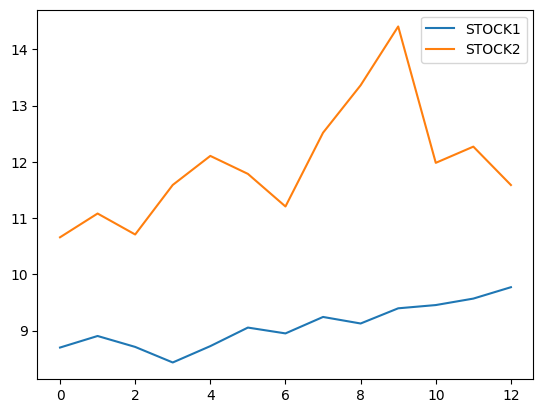

In [11]:
prices.plot()

### 1.2.2. 美国股市历史数据

来源：
- Kenneth French： https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/data_library.html#Research

# 2. 数据预处理 Data Preparation  <a id="2"></a>

# 3. 数据分析和探索，建模  Data Analysis & Data  Mining，Modelling <a id="3"></a>

## 3.1. 金融分析基础概念和模型

## 如何评估收益

基本收益指标：直观，简单好理解。

### 收益率（Returns）

return from time $t$ to time ${t+1} is given by:

$$ R_{t,t+1} = \frac{P_{t+1}-P_{t}}{P_{t}} $$

or alternately

$$ R_{t,t+1} = \frac{P_{t+1}}{P_{t}} - 1 $$


计算累计收益率时:
- 基于“复利式”计算方法：乘法因子 "1+R" format
- 回算收益率时需要做 -1 转换


In [19]:
# If you come from R or another language that supports vectors, you might expect something like this to work:

prices_a = np.array([10, 12, 14, 13, 15])
returns_a = prices_a[1:]/prices_a[:-1] - 1
returns_a

array([ 0.2       ,  0.16666667, -0.07142857,  0.15384615])

### 年化收益率（Annualizing Returns）

To annualize a return for a period, you compound the return for as many times as there are periods in a year. For instance, to annualize a monthly return you compund that return 12 times. The formula to annualize a monthly return $R_m$ is:

$$ (1+R_m)^{12} - 1$$

To annualize a quarterly return $R_q$ you would get:

$$ (1+R_q)^{4} - 1$$

And finally, to annualize a daily return $R_d$ you would get:

$$ (1+R_d)^{252} - 1$$

年化收益率的计算公式是**（投资内收益/本金/投资天数）×365×100%**。

对于复利投资，可以使用公式年化收益率 = (期末资产净值 / 期初资产净值)^365/投资天数- 1来计算。 
方法一：按天数计算（适用于非复利） 
•	公式：年化收益率 = (投资收益 / 本金 / 投资天数) × 365 × 100%
•	举例：
o	本金是10000元
o	投资了180天
o	获得了收益200元
o	年化收益率 = (200/10000/180) × 365 × 100% ≈ 4.06% 
方法二：复利计算 
•	公式：年化收益率 = (期末资产净值 / 期初资产净值)^(365/投资天)- 1
 
补充说明 
- 年化收益率是把当前收益率（日收益率、周收益率、月收益率）换算成年收益率来计算的，是一种**理论收益率**，并不是真正的已取得的收益率。
作用：提供一个可用衡量对比的基准
- 注意定义的模糊性： 有效时间的不同规定：一年的有效投资时间，对银行存款、票据、债券等D=360日，对于股票、期货等市场D=250日，对于房地产和实业等D=365日
- 在实际投资中，年化收益率会受市场波动等多种因素影响，可能与实际收益率不同。
- 对于货币基金、债券等有固定收益或定期调整收益的投资，实际收益率可能更接近年化收益率。 



## 如何评估风险

## 波动率（Volatility）

volatility is measured by the average squared deviation from the mean = standard deviation.

波动率是衡量金融资产价格在特定期间内波动程度的指标，通常以百分比或点数表示。它反映市场的活跃程度：波动率高代表价格剧烈波动，波动率低则表示价格相对稳定。


In [ ]:
returns = returns.dropna()
deviations = returns - returns.mean()
# deviations 
sq_deviations = deviations **2
#sq_deviations
meann_sq_dev = sq_deviations.mean()
# numpy
# volatility =  np.sqrt(meann_sq_dev)
#pandas
returns.std() 
volatility

STOCK1    0.022957
STOCK2    0.076212
dtype: float64

### Drawdown (The maximum drawdown)=max. loss回撤

回撤（或最大回撤）是另外一个（更真实）反应风险的评估指标。



## 从简单到晋级：如何在整体金融市场中评估收益

需要一下基本假设和基础模型。

### CAPM（资本资产定价模型）

CAPM（资本资产定价模型）是现代金融学最重要的模型，可以用来：计算资产的系统风险，估计资产的预期收益率，评价投资组合的业绩。 该模型在诺奖得主哈里·马科维茨（Harry Markowitz）的投资组合理论（又称均值方差理论）基础之上产生，由威廉·夏普（William Sharpe）正式提出

资本资产定价模型（CAPM）是现代金融理论中的一个基本概念，用于通过考虑投资相对于整体市场的内在风险来确定投资的预期回报率。 该模型提供了一种结构化的方法来评估风险和回报之间的权衡，这对于做出明智的投资决策来说是至关重要的。 资本资产定价模型中包含了三个主要的组成部分：无风险利率、β 系数和市场风险溢价

计算公式：
𝐸(𝑅𝑖)=𝑅𝑓+𝛽𝑖(𝐸(𝑅𝑚)−𝑅𝑓)

公式说明：
- 𝐸(𝑅𝑖)代表资产的预期收益率。
- 𝑅𝑓代表无风险利率。
- 𝛽𝑖代表资产的Beta值，衡量资产相对于市场波动的敏感度。
- 𝐸(𝑅𝑚)代表市场的平均预期收益率。
- (𝐸(𝑅𝑚)−𝑅𝑓)代表市场风险溢价。



## 4. 模型评估 Model Evaluation <a id="4"></a> 

## 5. 业务理解/知识深化和提升  <a id="5"></a> 